# CS4503: Data Analytics and Visualization Lab
## Experiment 2: Data Handling and Analysis

This experiment consists of four parts:
- **Part A:** Working with NumPy arrays
- **Part B:** Working with Pandas DataFrames
- **Part C:** Reading data from text files, Excel, and the web
- **Part D:** Exploring descriptive analytics using the Iris dataset


### Part A: Working with NumPy arrays
**AIM:** To understand and implement various NumPy operations, including array creation, indexing, slicing, element-wise operations, aggregations, boolean operations, fancy indexing, reshaping, and structured arrays.


In [1]:
import numpy as np

# Check NumPy version
print("NumPy Version:", np.__version__)

# Creating different types of arrays
arr_1d = np.array([1, 2, 3, 4, 5])
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])
arr_0d = np.array(42)
arr_ones = np.ones((3, 3))

print("1D Array:", arr_1d)
print("2D Array:\n", arr_2d)
print("0D Array:", arr_0d)
print("Ones Array:\n", arr_ones)

# Indexing and Slicing
print("\nElement at index 2 in 1D array:", arr_1d[2])
print("Element at row 1, column 2 in 2D array:", arr_2d[1, 2])
print("Slice from 1D array:", arr_1d[1:4])
print("Slice row 1 from 2D array:", arr_2d[1, :])

# Element-wise operations
arr_a = np.array([10, 20, 30])
arr_b = np.array([1, 2, 3])
print("\nAddition:", arr_a + arr_b)
print("Subtraction:", arr_a - arr_b)
print("Multiplication:", arr_a * arr_b)
print("Division:", arr_a / arr_b)
print("Scalar Multiplication:", arr_a * 2)

# Aggregations
print("\nSum:", np.sum(arr_a))
print("Mean:", np.mean(arr_a))
print("Standard Deviation:", np.std(arr_a))

# Element-wise comparison
print("Element-wise comparison:", arr_a > arr_b)

# Boolean masking
print("Elements greater than 15:", arr_a[arr_a > 15])

# Fancy Indexing
indices = [0, 2]
print("Selected elements:", arr_a[indices])

# Reshape
reshaped_arr = arr_1d.reshape(5, 1)
print("Reshaped 1D array to 2D:\n", reshaped_arr)

# Structured array
structured_arr = np.array([(25, 90.5), (30, 85.2)], dtype=[('age', 'i4'), ('score', 'f4')])
print("Structured array:", structured_arr)


NumPy Version: 2.4.4
1D Array: [1 2 3 4 5]
2D Array:
 [[1 2 3]
 [4 5 6]]
0D Array: 42
Ones Array:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Element at index 2 in 1D array: 3
Element at row 1, column 2 in 2D array: 6
Slice from 1D array: [2 3 4]
Slice row 1 from 2D array: [4 5 6]

Addition: [11 22 33]
Subtraction: [ 9 18 27]
Multiplication: [10 40 90]
Division: [10. 10. 10.]
Scalar Multiplication: [20 40 60]

Sum: 60
Mean: 20.0
Standard Deviation: 8.16496580927726
Element-wise comparison: [ True  True  True]
Elements greater than 15: [20 30]
Selected elements: [10 30]
Reshaped 1D array to 2D:
 [[1]
 [2]
 [3]
 [4]
 [5]]
Structured array: [(25, 90.5) (30, 85.2)]


### Part B: Exploring Pandas DataFrame Operations for Data Manipulation and Analysis
**AIM:** To explore and perform various DataFrame operations using Pandas, including loading datasets, data inspection, handling missing values, transformations, filtering, grouping, sorting, and saving results.


In [2]:
import pandas as pd
import numpy as np

# Load dataset into a DataFrame
df = pd.read_csv('data.csv')

# Display first and last few rows
print("First 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

# Check data types and general info
df.info()

# Summary statistics
print("\nSummary statistics:\n", df.describe())

# Handle missing values by filling only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Create a new column
df['new_column'] = df['existing_column'] * 2

# Create a Series and perform operations
series = df['existing_column']
print("\nSeries addition (existing_column + 10):\n", (series + 10).head())

# Filter rows based on conditions
filtered_df = df[(df['existing_column'] > 50) & (df['another_column'] < 100)]
print("\nFiltered DataFrame shape:", filtered_df.shape)

# Grouping and aggregation
grouped = df.groupby('category_column')['numeric_column'].mean()
print("\nGrouped mean:\n", grouped)

# Sorting
df_sorted = df.sort_values(by='numeric_column', ascending=False)
print("\nSorted DataFrame head:\n", df_sorted.head())

# Boolean masking
masked_df = df[df['numeric_column'] > df['numeric_column'].median()]
print("\nMasked DataFrame shape:", masked_df.shape)

# Remove duplicates and drop missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Create a new DataFrame with selected columns
subset_df = df[['column1', 'column2']]

# Save the new DataFrame to a CSV file
subset_df.to_csv('filtered_data.csv', index=False)

# Compute summary statistics
print("\nTotal sum of numeric_column:", df['numeric_column'].sum())
print("Mean of numeric_column:", df['numeric_column'].mean())
print("Standard Deviation of numeric_column:", df['numeric_column'].std())


First 5 rows:
    existing_column  another_column category_column  numeric_column   column1  \
0               61              98      Category B              66  0.549576   
1               24              80      Category B             221 -1.270872   
2               81              18      Category C             269  2.389036   
3               70              97      Category C             207  1.843414   
4               30             138      Category A              95  1.363435   

    column2  
0 -0.433303  
1  0.203823  
2  0.559109  
3  0.872542  
4  1.154354  

Last 5 rows:
     existing_column  another_column category_column  numeric_column   column1  \
95               50              47      Category A             493  1.770432   
96               38              33      Category A             150 -0.309093   
97               24              78      Category C             313  0.803813   
98               54             125      Category C             102  0.613841   


### Part C: Reading Data from Text Files, Excel, and the Web
**AIM:** To read and process data from various sources, including text files, Excel spreadsheets, and web-based data, using Python's Pandas library.


In [3]:
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Read data
text_df = pd.read_csv('Google_data (2b.c1).csv')
excel_df = pd.read_excel('data (2c2).xlsx', sheet_name='Sheet1')
web_df = pd.read_csv('https://raw.githubusercontent.com/cs109/2014_data/master/countries.csv')

# Display data
print("--- CSV Google Data Head ---")
print(text_df.head(2))
print("\n--- Excel Product Data Head ---")
print(excel_df.head(2))
print("\n--- Web Countries Data Head ---")
print(web_df.head(2))

# Handle missing values
# Use ffill() and bfill() methods directly to avoid pandas deprecation warning
if hasattr(text_df, 'ffill'):
    text_df.ffill(inplace=True)
else:
    text_df.fillna(method='ffill', inplace=True)

if hasattr(excel_df, 'bfill'):
    excel_df.bfill(inplace=True)
else:
    excel_df.fillna(method='bfill', inplace=True)

web_df.dropna(inplace=True)

# Save processed data
text_df.to_csv('processed_text.csv', index=False)
excel_df.to_excel('processed_excel.xlsx', index=False)
print("\nProcessed data saved to processed_text.csv and processed_excel.xlsx.")


--- CSV Google Data Head ---
     App   Category  Rating  Reviews Size  Installs  Type  Price  \
0  App 1     FAMILY     4.9   853089  55M  500,000+  Paid      0   
1  App 2  LIFESTYLE     3.4   830461  40M  100,000+  Paid  $0.99   

  Content Rating   Genres     Last Updated Current Ver   Android Ver  
0       Everyone  Medical  January 7, 2018       1.0.0  4.0.3 and up  
1           Teen  Medical  January 7, 2018       1.0.0  4.0.3 and up  

--- Excel Product Data Head ---
      Product  Price  Quantity
0      Laptop   1000         5
1  Smartphone    800         8

--- Web Countries Data Head ---
   Country  Region
0  Algeria  AFRICA
1   Angola  AFRICA

Processed data saved to processed_text.csv and processed_excel.xlsx.


### Part D: Exploring Descriptive Analytics Using the Iris Dataset
**AIM:** To explore descriptive analytics using the Iris dataset with Python's Pandas and Seaborn libraries.


Basic Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
None

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.40000

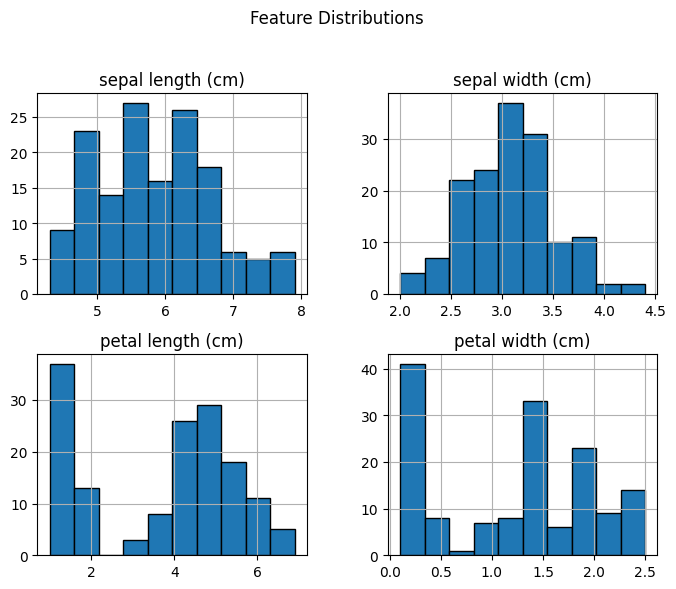

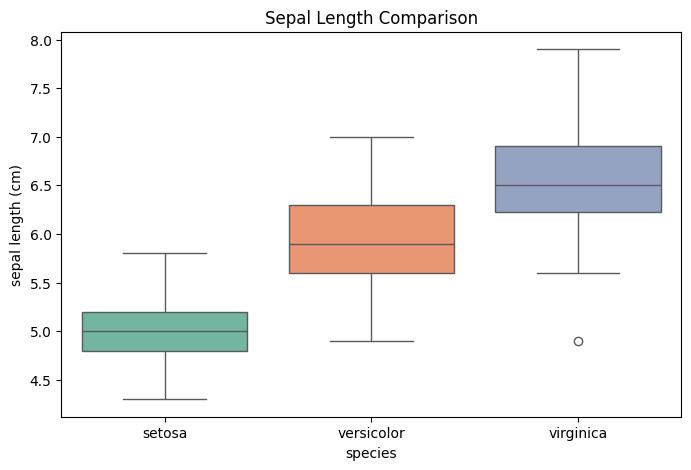

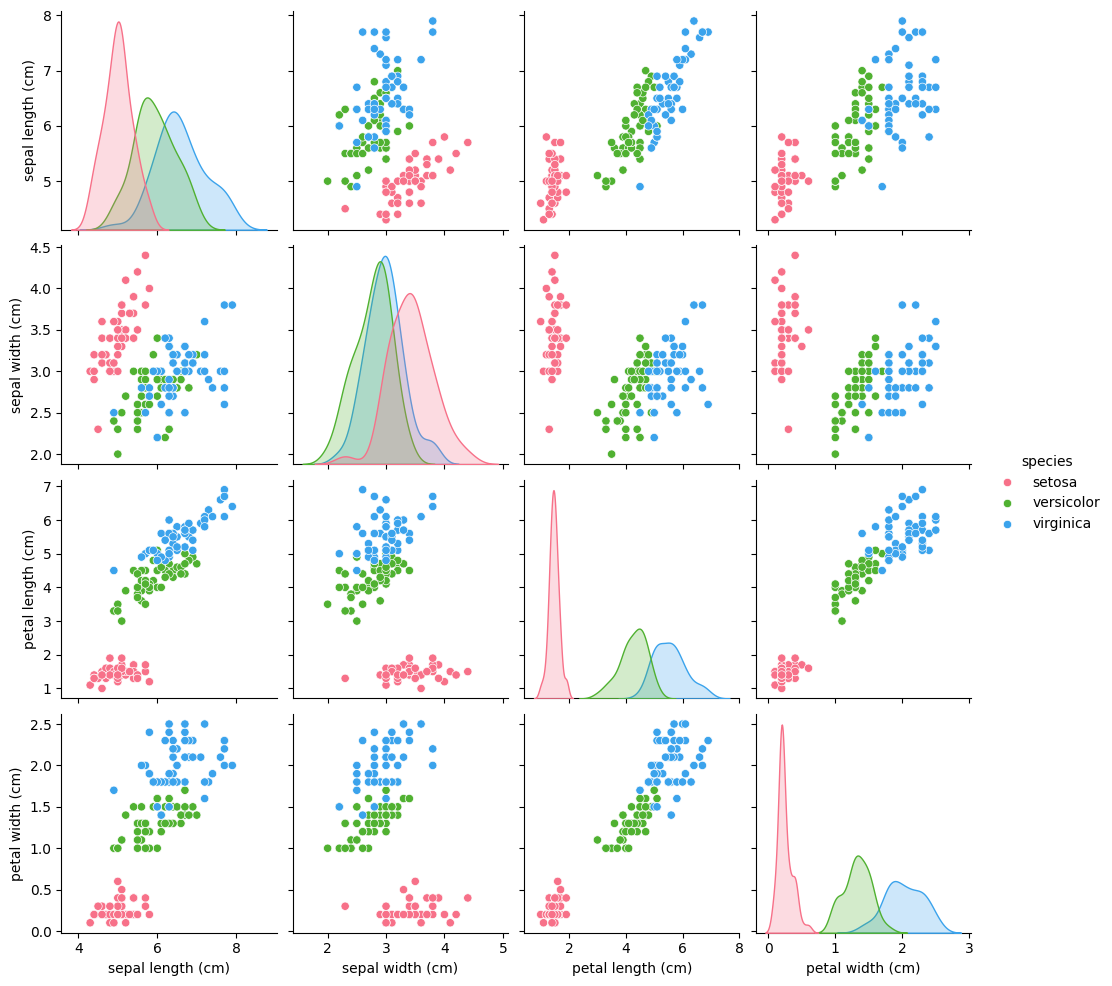

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('iris_dataset(2d).csv')

# Display basic information and summary statistics
print("Basic Information:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# Perform univariate analysis - species count
print("\nSpecies Count:")
print(df['species'].value_counts())

# Visualize data distributions using histograms
df.hist(figsize=(8, 6), edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.show()

# Boxplot for Sepal Length
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='sepal length (cm)', palette='Set2')
plt.title('Sepal Length Comparison')
plt.show()

# Pairplot to analyze feature relationships
sns.pairplot(df, hue='species', palette='husl')
plt.show()
